# Практическая работа №1. 

**Цель:** Исследование эффективности моделей машинного обучения для решения задачи классификации на примере решения задачи классификации трёх различных сортов итальянских вин» является демонстрация способности моделей машинного обучения решать задачи классификации


**Выполнила:** студентка группы 6231-090401D Ризванова Э.Т.

**Вариант 10:**
- Класс 1 - 0;
- Класс 2 - 1;
- Классификатор 1 - К-ближайших соседей (К=5);
- Классификатор 2 - Наивный байесовский классификатор.

### 1. Импорт всех нужных библиотек

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, f1_score

### 2. Выполнение задания

#### Загрузка набора данных:

In [2]:
data = load_wine()
X = data.data
Y = data.target
feature_names = data.feature_names

print('Количество образцов:', X.shape[0])
print('Количество признаков:', X.shape[1])
print('Названия признаков:', feature_names)
print('Матрица признаков:')
print(X)
print('Метки:')
print(Y)

Количество образцов: 178
Количество признаков: 13
Названия признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Матрица признаков:
[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
Метки:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 

#### Подготовка данных:

In [3]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = Y

df_filtered = df[df['target'].isin([0, 1])]
X_filtered = df_filtered.drop('target', axis=1)
Y_filtered = df_filtered['target']

print('Количество образцов после фильтрации:', df_filtered.shape[0])
print('Количество образцов класса 0:', sum(Y_filtered == 0))
print('Количество образцов класса 1:', sum(Y_filtered == 1))

Количество образцов после фильтрации: 130
Количество образцов класса 0: 59
Количество образцов класса 1: 71


#### Диаграмма рассеивания для всех пар признаков:

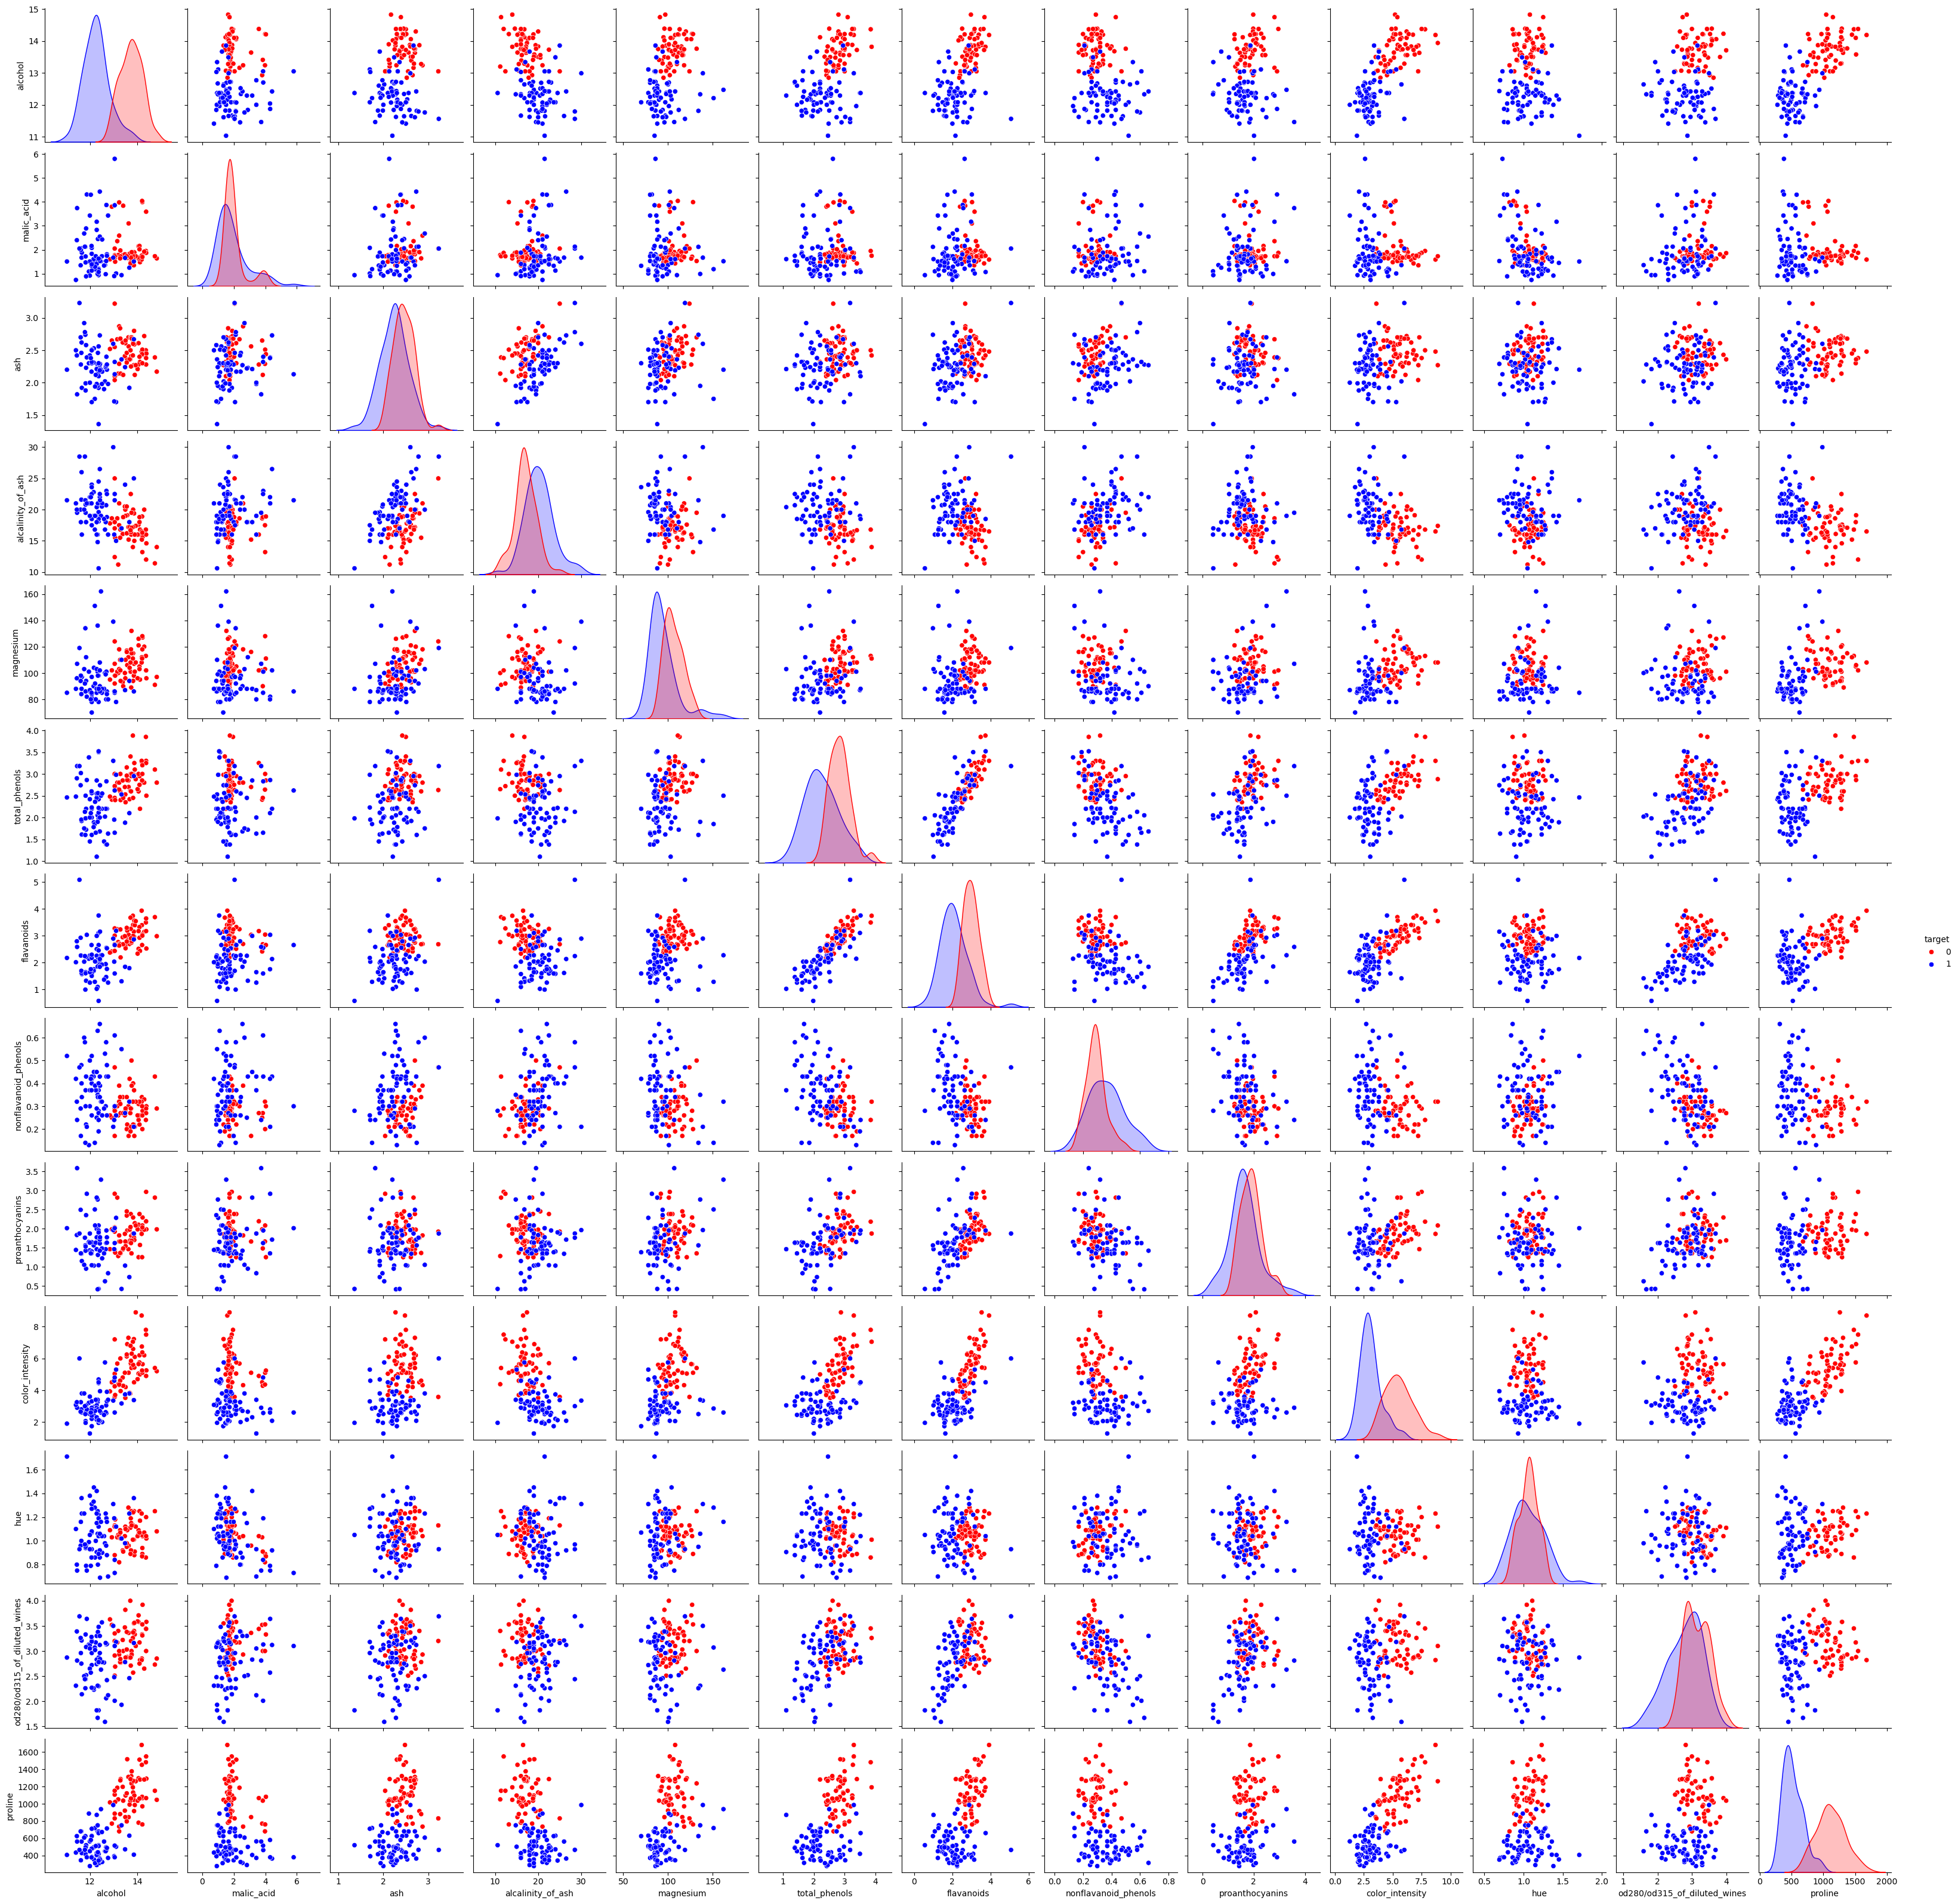

In [4]:
sns.pairplot(df_filtered, hue='target', palette={0:'red', 1:'blue'}, vars=feature_names)
plt.show()

#### Разделение выборки:

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X_filtered, Y_filtered, test_size=0.4, random_state=42)

print('Количество образцов в обучающей выборке:', X_train.shape[0])
print('Количество образцов в тестовой выборке:', X_test.shape[0])

Количество образцов в обучающей выборке: 78
Количество образцов в тестовой выборке: 52


#### Нормализация:

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Среднее по каждому признаку:', X_train.mean(axis=0))
print('Отклонение по каждому признаку:', X_train.std(axis=0))

Среднее по каждому признаку: [-4.76826555e-16 -5.33761070e-17  2.42683366e-15  1.38635542e-15
  3.18833279e-16  2.74353190e-16 -6.73962310e-16 -4.02989607e-17
  3.82884607e-16  6.47630098e-16  4.61169564e-16  2.72858659e-15
  1.72226905e-16]
Отклонение по каждому признаку: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 3. Классификатор 1. К-ближайших соседей

#### Обучение и тестирование:

In [ ]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, Y_train)

Y_predict_knn = knn_clf.predict(X_test)
print(classification_report(Y_test, Y_predict_knn, digits=3))

              precision    recall  f1-score   support

           0      0.900     1.000     0.947        27
           1      1.000     0.880     0.936        25

    accuracy                          0.942        52
   macro avg      0.950     0.940     0.942        52
weighted avg      0.948     0.942     0.942        52



#### График ROC кривой:

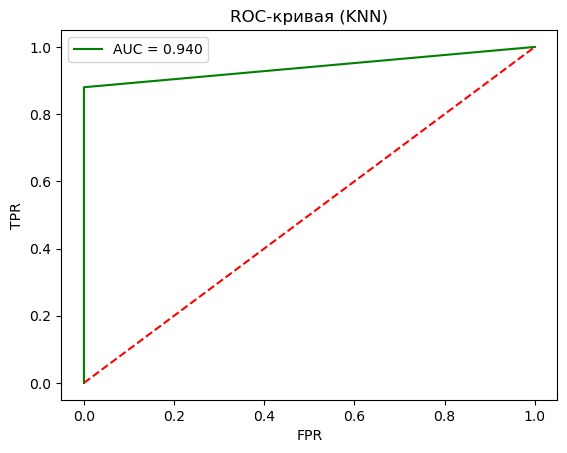

In [8]:
fpr_knn, tpr_knn, _ = roc_curve(Y_test, Y_predict_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure()
plt.plot(fpr_knn, tpr_knn, color='green', label=f'AUC = {auc_knn:.3f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC-кривая (KNN)')
plt.legend()
plt.show()

#### Матрица ошибок:

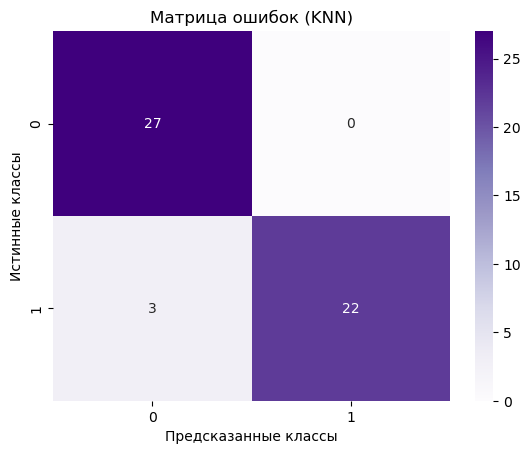

In [9]:
cm_knn = confusion_matrix(Y_test, Y_predict_knn)

plt.figure()
sns.heatmap(cm_knn, annot=True, cmap='Purples')
plt.xlabel('Предсказанные классы')
plt.ylabel('Истинные классы')
plt.title('Матрица ошибок (KNN)')
plt.show()

### 4. Классификатор 2. Наивный байесовский классификатор

#### Обучение и тестирование:

In [10]:
nb_clf = GaussianNB()
nb_clf.fit(X_train, Y_train)

Y_predict_nb = nb_clf.predict(X_test)

print(classification_report(Y_test, Y_predict_nb, digits=3))

              precision    recall  f1-score   support

           0      0.963     0.963     0.963        27
           1      0.960     0.960     0.960        25

    accuracy                          0.962        52
   macro avg      0.961     0.961     0.961        52
weighted avg      0.962     0.962     0.962        52



#### График ROC кривой:

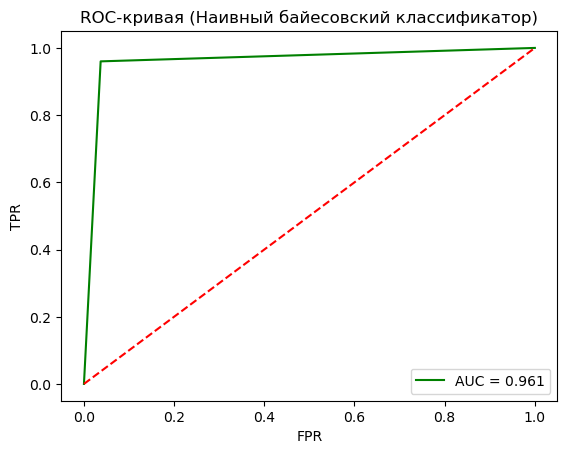

In [11]:
fpr_nb, tpr_nb, _ = roc_curve(Y_test, Y_predict_nb)
auc_nb = auc(fpr_nb, tpr_nb)

plt.figure()
plt.plot(fpr_nb, tpr_nb, color='green', label=f'AUC = {auc_nb:.3f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC-кривая (Наивный байесовский классификатор)')
plt.legend()
plt.show()

#### Матрица ошибок:

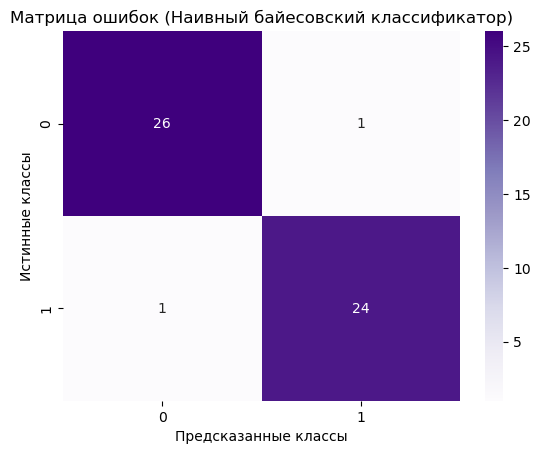

In [12]:
cm_nb = confusion_matrix(Y_test, Y_predict_nb)

plt.figure()
sns.heatmap(cm_nb, annot=True, cmap='Purples')
plt.xlabel('Предсказанные классы')
plt.ylabel('Истинные классы')
plt.title('Матрица ошибок (Наивный байесовский классификатор)')
plt.show()

#### Сравнение классификаторов:

In [13]:
f1_knn = f1_score(Y_test, Y_predict_knn)
f1_nb = f1_score(Y_test, Y_predict_nb)

if f1_knn > f1_nb:
    print("По критерию F1 лучше KNN.")
else:
    print("По критерию F1 лучше Наивный байесовский классификатор.")

if auc_knn > auc_nb:
    print("По критерию AUC лучше KNN.")
else:
    print("По критерию AUC лучше Наивный байесовский классификатор.")

По критерию F1 лучше Наивный байесовский классификатор.
По критерию AUC лучше Наивный байесовский классификатор.
